In [2]:
import pandas as pd
import os

# CORRECTED: Use os.getcwd() instead of __file__ for Jupyter Notebooks
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "global_movies_dataset_1950_2026.csv")

print("Loading dataset for local analysis...")
print(f"Target path: {CSV_PATH}")

# Load the dataset
try:
    df = pd.read_csv(CSV_PATH)
    print("✨ Success! Dataset loaded into 'df'.")
    print(f"Total rows loaded: {len(df)}")
except FileNotFoundError:
    print("❌ Error: Could not find the CSV file. Please double-check your folder structure.")


Loading dataset for local analysis...
Target path: d:\Projects\global-movies-dashboard\backend\global_movies_dataset_1950_2026.csv
✨ Success! Dataset loaded into 'df'.
Total rows loaded: 100000


In [4]:
import pandas as pd
import os

# CORRECTED: Uses os.getcwd() for Jupyter Notebook compatibility
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "global_movies_dataset_1950_2026.csv")

print("Loading dataset for local analysis...")
df = pd.read_csv(CSV_PATH)

print("\n==================================================")
print(" 🎬 1. CORE EDA & DATASET SUMMARY")
print("==================================================")
print(f"Total Movies Cataloged: {len(df):,}")
print(f"Release Year Range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"Average IMDb Rating: {df['imdb_rating'].mean():.2f} (Min: {df['imdb_rating'].min()}, Max: {df['imdb_rating'].max()})")
print(f"Cumulative Global Revenue: ${df['revenue_million'].sum() / 1000:,.2f} Billion")
print(f"Average Return on Investment (ROI): {df['roi_pct'].mean():.2f}%")

print("\n==================================================")
print(" 📈 2. TIME-SERIES RATING & VOLUME TRENDS BY DECADE")
print("==================================================")
decade_trends = df.groupby('decade').agg(
    movie_count=('movie_id', 'count'),
    avg_imdb_rating=('imdb_rating', 'mean'),
    avg_audience_score=('audience_score', 'mean'),
    avg_revenue_million=('revenue_million', 'mean')
).reset_index()
print(decade_trends.to_string(index=False))

print("\n==================================================")
print(" 📊 3. STREAMING PLATFORM PERFORMANCE")
print("==================================================")
platform_perf = df.groupby('streaming_platform').agg(
    movie_count=('movie_id', 'count'),
    total_revenue_billion=('revenue_million', lambda x: round(x.sum() / 1000, 2)),
    avg_roi_pct=('roi_pct', lambda x: round(x.mean(), 2)),
    avg_imdb_rating=('imdb_rating', lambda x: round(x.mean(), 2))
).reset_index().sort_values(by='total_revenue_billion', ascending=False)
print(platform_perf.to_string(index=False))


Loading dataset for local analysis...

 🎬 1. CORE EDA & DATASET SUMMARY
Total Movies Cataloged: 100,000
Release Year Range: 1950 – 2026
Average IMDb Rating: 6.74 (Min: 2.2, Max: 9.8)
Cumulative Global Revenue: $13,331.38 Billion
Average Return on Investment (ROI): 176.87%

 📈 2. TIME-SERIES RATING & VOLUME TRENDS BY DECADE
 decade  movie_count  avg_imdb_rating  avg_audience_score  avg_revenue_million
   1950        12938         6.809522           70.333668           138.932602
   1960        12997         6.805278           70.435716           131.896391
   1970        13099         6.710573           69.575540           131.097799
   1980        12981         6.697373           69.485787           133.287946
   1990        13008         6.706573           69.531750           132.103690
   2000        12734         6.723755           69.589917           134.008223
   2010        13137         6.709645           69.409911           134.018067
   2020         9106         6.723808      

In [6]:
# Overview statistics
summary_stats = pd.DataFrame({
    "Metric": ["Total Movies", "Release Year Span", "Mean IMDb Rating", "Median IMDb Rating", "Total Revenue ($B)", "Average ROI (%)"],
    "Value": [
        f"{len(df):,}",
        f"{df['release_year'].min()} - {df['release_year'].max()}",
        f"{df['imdb_rating'].mean():.2f}",
        f"{df['imdb_rating'].median():.2f}",
        f"${df['revenue_million'].sum() / 1000:,.2f}B",
        f"{df['roi_pct'].mean():.2f}%"
    ]
})
summary_stats

,Metric,Value
0,Total Movies,"100,000"
1,Release Year Span,1950 - 2026
2,Mean IMDb Rating,6.74
3,Median IMDb Rating,6.70
4,Total Revenue ($B),"$13,331.38B"
5,Average ROI (%),176.87%


,decade,movie_count,avg_imdb_rating,avg_audience_score,avg_revenue_million
0,1950,12938,6.809522,70.333668,138.932602
1,1960,12997,6.805278,70.435716,131.896391
2,1970,13099,6.710573,69.575540,131.097799
3,1980,12981,6.697373,69.485787,133.287946
4,1990,13008,6.706573,69.531750,132.103690
5,2000,12734,6.723755,69.589917,134.008223
6,2010,13137,6.709645,69.409911,134.018067
7,2020,9106,6.723808,69.475840,130.319986


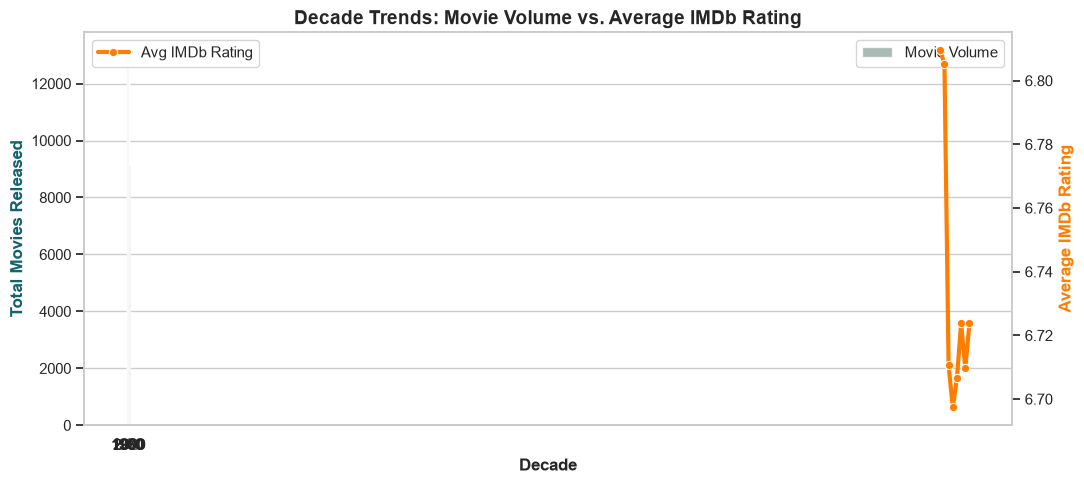

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")

# Aggregate by decade
decade_trends = df.groupby('decade').agg(
    movie_count=('movie_id', 'count'),
    avg_imdb_rating=('imdb_rating', 'mean'),
    avg_audience_score=('audience_score', 'mean'),
    avg_revenue_million=('revenue_million', 'mean')
).reset_index()

display(decade_trends)

# Visualizing production volume vs ratings over decades
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.set_title('Decade Trends: Movie Volume vs. Average IMDb Rating', fontsize=14, fontweight='bold')

sns.barplot(data=decade_trends, x='decade', y='movie_count', ax=ax1, color='#8AA79F', alpha=0.75, label='Movie Volume')
ax1.set_ylabel('Total Movies Released', color='#15616D', fontweight='bold')
ax1.set_xlabel('Decade', fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=decade_trends, x='decade', y='avg_imdb_rating', ax=ax2, color='#FF7D00', marker='o', linewidth=3, label='Avg IMDb Rating')
ax2.set_ylabel('Average IMDb Rating', color='#FF7D00', fontweight='bold')
ax2.grid(False)

plt.tight_layout()
plt.show()

In [10]:
import sys
print("Current Python Executable:", sys.executable)

Current Python Executable: d:\Projects\hrm-executive-dashboard\.venv\Scripts\python.exe


In [11]:
import sys
!{sys.executable} -m pip install seaborn matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,streaming_platform,movie_count,total_revenue_billion,avg_revenue_million,avg_roi_pct,avg_imdb_rating
4,Hulu,9977,1381.68,138.49,179.59,6.76
5,MGM+,10119,1370.28,135.42,175.32,6.74
0,Apple TV+,10167,1350.17,132.80,176.75,6.74
2,Disney+,9986,1336.93,133.88,179.10,6.73
1,Cinema,10067,1329.08,132.02,179.13,6.75
9,Prime Video,9990,1325.44,132.68,176.95,6.74
8,Peacock,9944,1322.93,133.04,176.08,6.72
7,Paramount+,9966,1319.33,132.38,174.58,6.74
6,Netflix,9925,1312.92,132.28,176.94,6.72
3,HBO Max,9859,1282.61,130.10,174.25,6.73


C:\Users\JK\AppData\Local\Temp\ipykernel_18388\493276239.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_perf, x='streaming_platform', y='total_revenue_billion', palette='Blues_r')


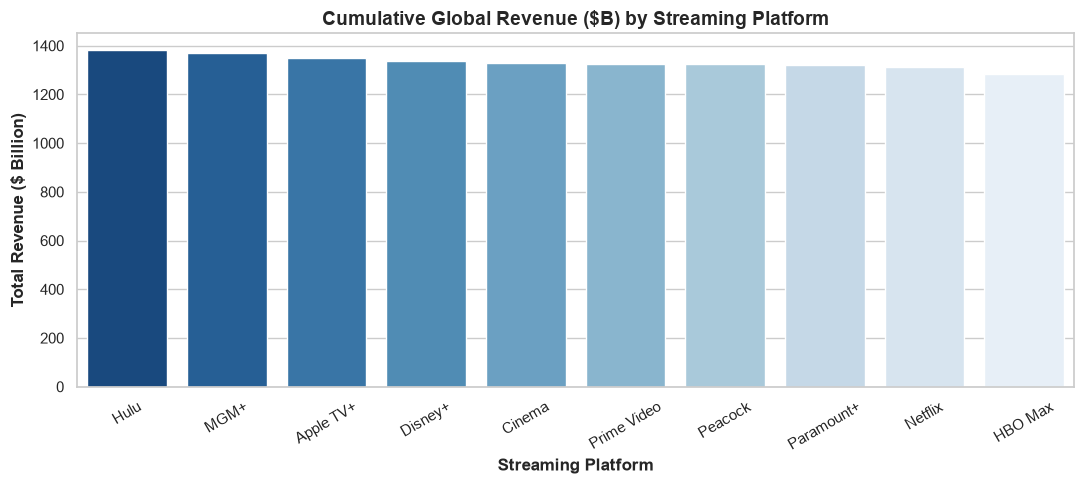

In [13]:
# Aggregate by streaming platform
platform_perf = df.groupby('streaming_platform').agg(
    movie_count=('movie_id', 'count'),
    total_revenue_billion=('revenue_million', lambda x: round(x.sum() / 1000, 2)),
    avg_revenue_million=('revenue_million', lambda x: round(x.mean(), 2)),
    avg_roi_pct=('roi_pct', lambda x: round(x.mean(), 2)),
    avg_imdb_rating=('imdb_rating', lambda x: round(x.mean(), 2))
).reset_index().sort_values(by='total_revenue_billion', ascending=False)

display(platform_perf)

# Visualizing platform revenue
plt.figure(figsize=(11, 5))
sns.barplot(data=platform_perf, x='streaming_platform', y='total_revenue_billion', palette='Blues_r')
plt.title('Cumulative Global Revenue ($B) by Streaming Platform', fontsize=14, fontweight='bold')
plt.xlabel('Streaming Platform', fontweight='bold')
plt.ylabel('Total Revenue ($ Billion)', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [18]:
display(genre_encoded_df.head(3))

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Fantasy,Horror,Mystery,Romance,Sci-Fi,Thriller
0,1,0,0,0,0,0,1,0,0,0,0,1,0
1,0,0,1,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,1,0


In [16]:
# Check total count of 1s vs 0s in your genre dataframe
print(genre_encoded_df.sum())

Action         14791
Adventure      14481
Animation      14595
Comedy         14613
Crime          14497
Documentary    14625
Drama          14719
Fantasy        14538
Horror         14702
Mystery        14404
Romance        14472
Sci-Fi         14518
Thriller       14742
dtype: int64


In [19]:
# Analyze top directors/cast members by cumulative revenue and average rating
# Assuming columns like 'director' and 'main_cast' exist in your dataset
if 'director' in df.columns:
    director_perf = df.groupby('director').agg(
        movie_count=('movie_id', 'count'),
        total_revenue_million=('revenue_million', 'sum'),
        avg_imdb_rating=('imdb_rating', 'mean')
    ).reset_index().sort_values(by='total_revenue_million', ascending=False)

    print("Top 10 Directors by Box Office Revenue:")
    display(director_perf.head(10))
else:
    print("Director column not found. Checking available columns:", df.columns.tolist())

Top 10 Directors by Box Office Revenue:


,director,movie_count,total_revenue_million,avg_imdb_rating
6,Patty Jenkins,9992,1369851.61,6.760969
4,James Cameron,9939,1340656.33,6.731381
0,Bong Joon-ho,9899,1339799.16,6.735802
1,Christopher Nolan,10066,1339715.90,6.730846
5,Martin Scorsese,9956,1335614.36,6.711701
9,Steven Spielberg,10053,1335166.97,6.741987
3,Greta Gerwig,10096,1329481.41,6.732696
7,Quentin Tarantino,10053,1323442.92,6.735134
8,Sofia Coppola,10037,1323098.27,6.743389
2,Denis Villeneuve,9909,1294556.01,6.738127


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Define Target and Features
df['is_hit'] = (df['imdb_rating'] >= 7.0).astype(int)

# Select numeric or encoded features (e.g., genre matrix combined with other metrics)
X = genre_encoded_df.copy() # You can add runtime, decade, etc. here
y = df['is_hit']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Fast Random Forest Baseline
clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.88      0.71     11602
           1       0.51      0.17      0.25      8398

    accuracy                           0.58     20000
   macro avg       0.55      0.52      0.48     20000
weighted avg       0.56      0.58      0.52     20000



In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Ensure target is defined
df['is_hit'] = (df['imdb_rating'] >= 7.0).astype(int)

# 2. Select available numeric/structural features to combine with genres
potential_features = ['runtime', 'decade', 'budget_million', 'vote_count']
active_features = [col for col in potential_features if col in df.columns]
print(f"Merging genre matrix with additional features: {active_features}")

# Combine genre one-hot matrix with numerical features
X_additional = df[active_features].fillna(0)
X = pd.concat([genre_encoded_df.reset_index(drop=True), X_additional.reset_index(drop=True)], axis=1)
y = df['is_hit']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Retrain Random Forest Classifier
clf_expanded = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_expanded.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = clf_expanded.predict(X_test)
print(classification_report(y_test, y_pred))

Merging genre matrix with additional features: ['decade', 'budget_million']
              precision    recall  f1-score   support

           0       0.59      0.61      0.60     11602
           1       0.44      0.42      0.43      8398

    accuracy                           0.53     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.53      0.53      0.53     20000



In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Ensure target definition
df['is_hit'] = (df['imdb_rating'] >= 7.0).astype(int)

# 2. Gather all available numeric features
numeric_cols = ['runtime', 'vote_count', 'revenue_million', 'decade', 'budget_million']
active_numeric = [col for col in numeric_cols if col in df.columns]

# 3. Encode categorical features (like streaming platform if present)
feature_dfs = [
    genre_encoded_df.reset_index(drop=True), 
    df[active_numeric].fillna(0).reset_index(drop=True)
]

if 'streaming_platform' in df.columns:
    platform_encoded = pd.get_dummies(df['streaming_platform'], prefix='platform', drop_first=True)
    feature_dfs.append(platform_encoded.reset_index(drop=True))

# Combine all feature matrices into a single X matrix
X = pd.concat(feature_dfs, axis=1)
y = df['is_hit']

print(f"Total feature columns fed into model: {X.shape[1]}")

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Optimized Random Forest with Balanced Weights
clf_optimized = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_optimized.fit(X_train, y_train)

# 6. Evaluate Performance
y_pred = clf_optimized.predict(X_test)
print(classification_report(y_test, y_pred))

Total feature columns fed into model: 25
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11602
           1       0.52      0.59      0.55      8398

    accuracy                           0.60     20000
   macro avg       0.59      0.60      0.59     20000
weighted avg       0.61      0.60      0.60     20000



In [23]:
import joblib

# Save the optimized random forest model and the fitted MultiLabelBinarizer
joblib.dump(clf_optimized, 'movie_hit_model.pkl')
joblib.dump(mlb, 'mlb_transformer.pkl')

print("Model and MultiLabelBinarizer saved successfully!")

Model and MultiLabelBinarizer saved successfully!
